# Limite Cinemático da fonte Tl-204

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.odr import ODR, Model, RealData
from scipy.special import factorial
import re

In [73]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')  

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def linear(x, m, b):
        return m * x + b 

# Valores a 10 casas decimais
M_CALIB = 0.0053690352
B_CALIB = 0.0235248553
M_CALIB_SIGMA = 0.0000648034
B_CALIB_SIGMA = 0.0072530131

def calib(channels, sigma_channels=None):
    energy = linear(channels, M_CALIB, B_CALIB)
    if sigma_channels is not None:
        sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + (M_CALIB * sigma_channels)**2 + B_CALIB_SIGMA**2)
    else:
         sigma_energy = np.sqrt((M_CALIB_SIGMA * channels)**2 + B_CALIB_SIGMA**2)
    return energy, sigma_energy

electron_mass_ene = 0.5109989461
alpha = 1/137.035999084
c = 299792458

def kurie(energy, counts, Z, sigma_energy=None):
    if sigma_energy is None:
        sigma_ene = np.zeros_like(energy)
    else: sigma_ene = sigma_energy
    energy_total = energy + electron_mass_ene
    p_times_c = np.sqrt(energy**2 + 2*energy*electron_mass_ene)
    sigma_p_times_c = (energy + electron_mass_ene) / p_times_c * sigma_ene

    #fermi
    beta = p_times_c / energy_total
    sigma_beta = np.sqrt((sigma_p_times_c / energy_total)**2 + (p_times_c * sigma_ene / energy_total**2)**2)
    x = 2 * np.pi * alpha * Z / beta
    sigma_x = x * sigma_beta / beta
    F = x / (1 - np.exp(-x))
    sigma_F = (np.exp(x) * (np.exp(x) - x - 1))/(np.exp(x)-1)**2 * sigma_x

    #kurie

    K = np.sqrt(counts / (p_times_c * energy_total * F))
    sigma_K = 0.5 * K * np.sqrt((sigma_p_times_c / p_times_c)**2 + (sigma_ene / energy_total)**2 + (sigma_F / F)**2)

    return K, sigma_K

# Tl-204: Limite Cinemático

A função de Kurie, $K(E)$, satisfaz
$$K(E) = \sqrt{\frac{N(E)}{pEF(Z,E)}}\propto E_{max}-E$$
Assim, encontrar o limite cinemático do decaimento $\beta^-$ equivale a encontrar o zero de $K(E)$

Fonte coberta

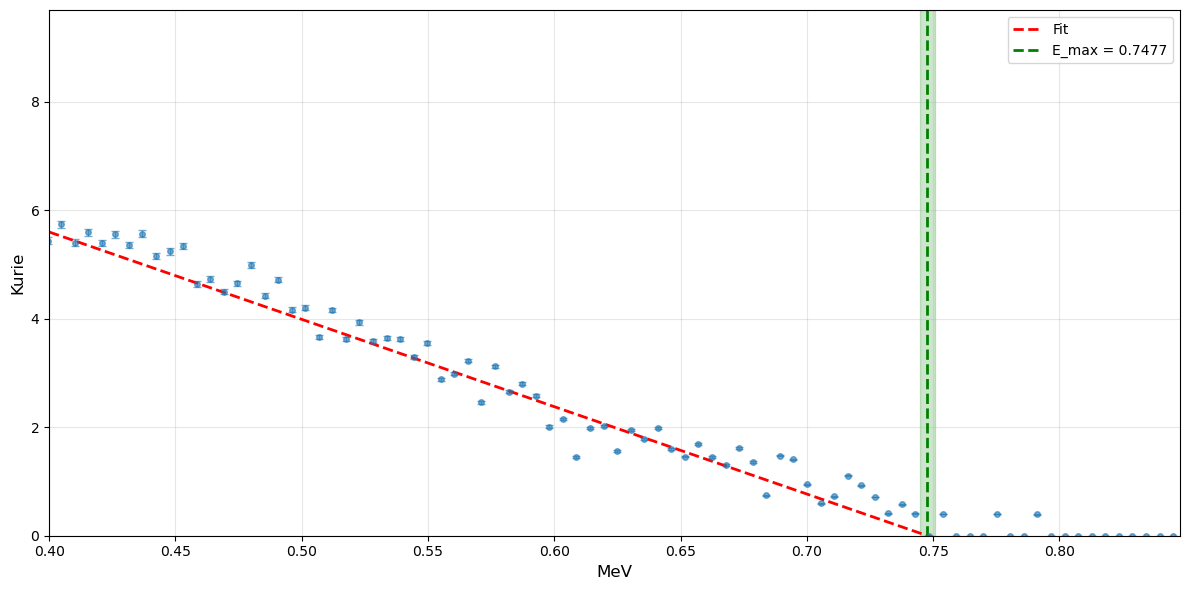

χ² = 0.043335
E_max = 0.7477 ± 0.0029 MeV


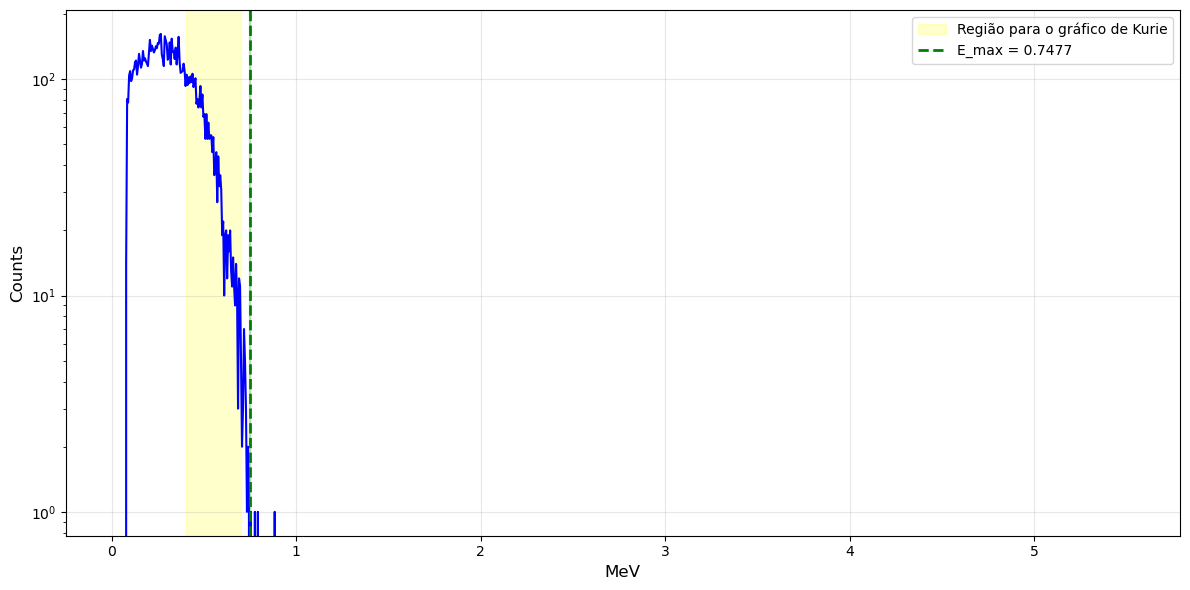

In [74]:
Z = 82 
channels_tl1, counts_tl1 = load_spectrum('TLINV.ASC')
energies_tl1, sigma_energies_tl1 = calib(channels_tl1)

tl1_roi_min, tl1_roi_max = 0.4, 0.7
tl1_roi = (energies_tl1 >= tl1_roi_min) & (energies_tl1 <= tl1_roi_max)

kurie_tl1, sigma_kurie_tl1 = kurie(energies_tl1, counts_tl1, Z, sigma_energy=sigma_energies_tl1)

popt, pcovt = optimize.curve_fit(linear, energies_tl1[tl1_roi], kurie_tl1[tl1_roi], sigma=sigma_kurie_tl1[tl1_roi], absolute_sigma=True)
perr = np.sqrt(np.diag(pcovt))

energy_max_tl1 = -popt[1] / popt[0]
sigma_energy_max_tl1 = np.sqrt((perr[1] / popt[0])**2 + (popt[1] * perr[0] / popt[0]**2)**2)

chi2_red = compute_chi2(kurie_tl1[tl1_roi], linear(energies_tl1[tl1_roi], *popt), dof=len(energies_tl1[tl1_roi])-2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(energies_tl1, kurie_tl1, yerr=sigma_kurie_tl1, fmt='o', markersize=4, capsize=3, elinewidth=1, alpha=0.6)
E_kurie = np.linspace(tl1_roi_min, energy_max_tl1 + 0.1, 100)
ax.plot(E_kurie, linear(E_kurie, *popt), 'r--', linewidth=2, label='Fit')
ax.axvline(energy_max_tl1, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl1:.4f}')
ax.axvspan(energy_max_tl1 - sigma_energy_max_tl1, energy_max_tl1 + sigma_energy_max_tl1, alpha=0.2, color='green')
ax.set_xlim(tl1_roi_min, energy_max_tl1 + 0.1)
ax.set_ylim(bottom=0)
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Kurie', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"χ² = {chi2_red:.6f}")
print(f"E_max = {energy_max_tl1:.4f} ± {sigma_energy_max_tl1:.4f} MeV")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_tl1, counts_tl1, 'b-', linewidth=1.5)
ax.axvspan(tl1_roi_min, tl1_roi_max, alpha=0.2, color='yellow', label='Região para o gráfico de Kurie')
ax.axvline(energy_max_tl1, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl1:.4f}')
ax.axvspan(energy_max_tl1 - sigma_energy_max_tl1, energy_max_tl1 + sigma_energy_max_tl1, alpha=0.2, color='green')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Fonte descoberta

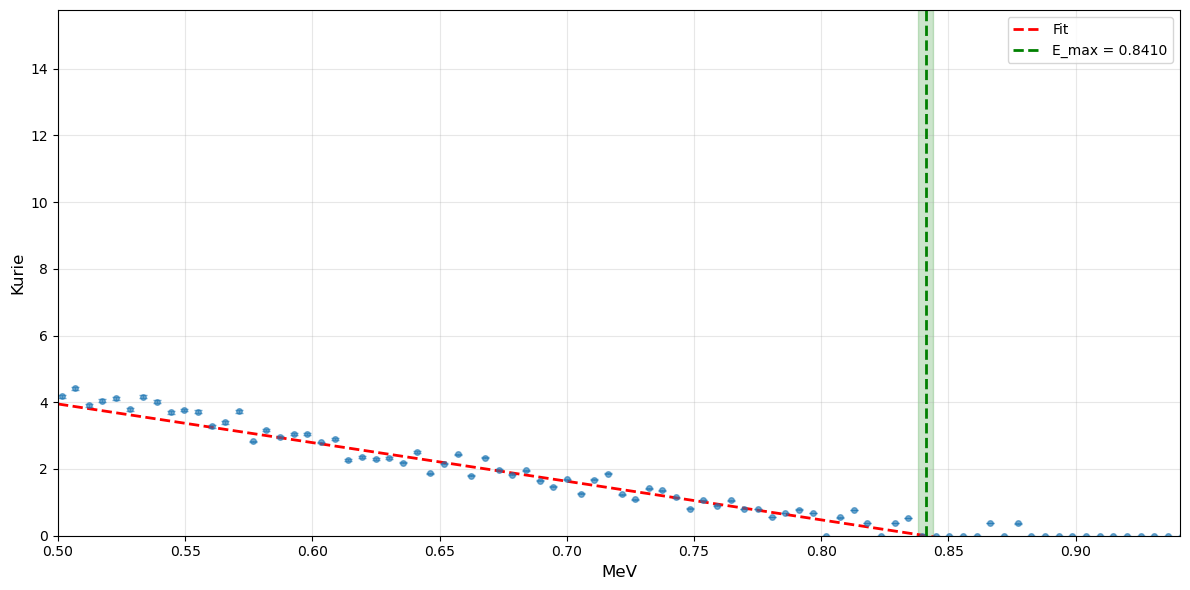

χ² = 0.029882
E_max = 0.8410 ± 0.0029 MeV


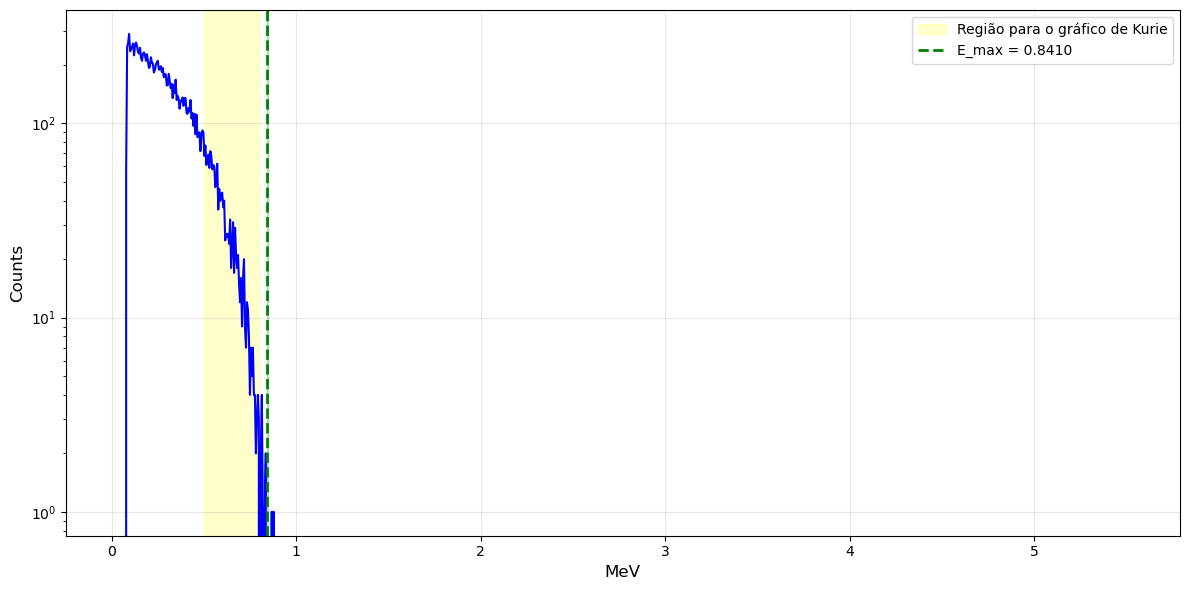

In [75]:
Z = 82 
channels_tl2, counts_tl2 = load_spectrum('TLSINV.ASC')
energies_tl2, sigma_energies_tl2 = calib(channels_tl2)

tl2_roi_min, tl2_roi_max = 0.5, 0.8
tl2_roi = (energies_tl2 >= tl2_roi_min) & (energies_tl2 <= tl2_roi_max)

kurie_tl2, sigma_kurie_tl2 = kurie(energies_tl2, counts_tl2, Z, sigma_energy=sigma_energies_tl2)

popt, pcovt = optimize.curve_fit(linear, energies_tl2[tl2_roi], kurie_tl2[tl2_roi], sigma=sigma_kurie_tl2[tl2_roi], absolute_sigma=True)
perr = np.sqrt(np.diag(pcovt))

energy_max_tl2 = -popt[1] / popt[0]
sigma_energy_max_tl2 = np.sqrt((perr[1] / popt[0])**2 + (popt[1] * perr[0] / popt[0]**2)**2)

chi2_red = compute_chi2(kurie_tl2[tl2_roi], linear(energies_tl2[tl2_roi], *popt), dof=len(energies_tl2[tl2_roi])-2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(energies_tl2, kurie_tl2, yerr=sigma_kurie_tl2, fmt='o', markersize=4, capsize=3, elinewidth=1, alpha=0.6)
E_kurie = np.linspace(tl2_roi_min, energy_max_tl2 + 0.1, 100)
ax.plot(E_kurie, linear(E_kurie, *popt), 'r--', linewidth=2, label='Fit')
ax.axvline(energy_max_tl2, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl2:.4f}')
ax.axvspan(energy_max_tl2 - sigma_energy_max_tl2, energy_max_tl2 + sigma_energy_max_tl2, alpha=0.2, color='green')
ax.set_xlim(tl2_roi_min, energy_max_tl2 + 0.1)
ax.set_ylim(bottom=0)
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Kurie', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"χ² = {chi2_red:.6f}")
print(f"E_max = {energy_max_tl2:.4f} ± {sigma_energy_max_tl2:.4f} MeV")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_tl2, counts_tl2, 'b-', linewidth=1.5)
ax.axvspan(tl2_roi_min, tl2_roi_max, alpha=0.2, color='yellow', label='Região para o gráfico de Kurie')
ax.axvline(energy_max_tl2, color='green', linestyle='--', linewidth=2, label=f'E_max = {energy_max_tl2:.4f}')
ax.axvspan(energy_max_tl2 - sigma_energy_max_tl2, energy_max_tl2 + sigma_energy_max_tl2, alpha=0.2, color='green')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Bi-207: Eletrões de conversão

$$E_e=E_\gamma-E_i$$
onde $E_e$ é a energia do eletrão, $E_\gamma$ é a energia de transição e $E_i$ é a energia da camada $i$.
Assim, para as duas energias de transição $$E_\gamma \in \left\{ 569{,}7; \; 1063{,}7 \right\}$$ temos:


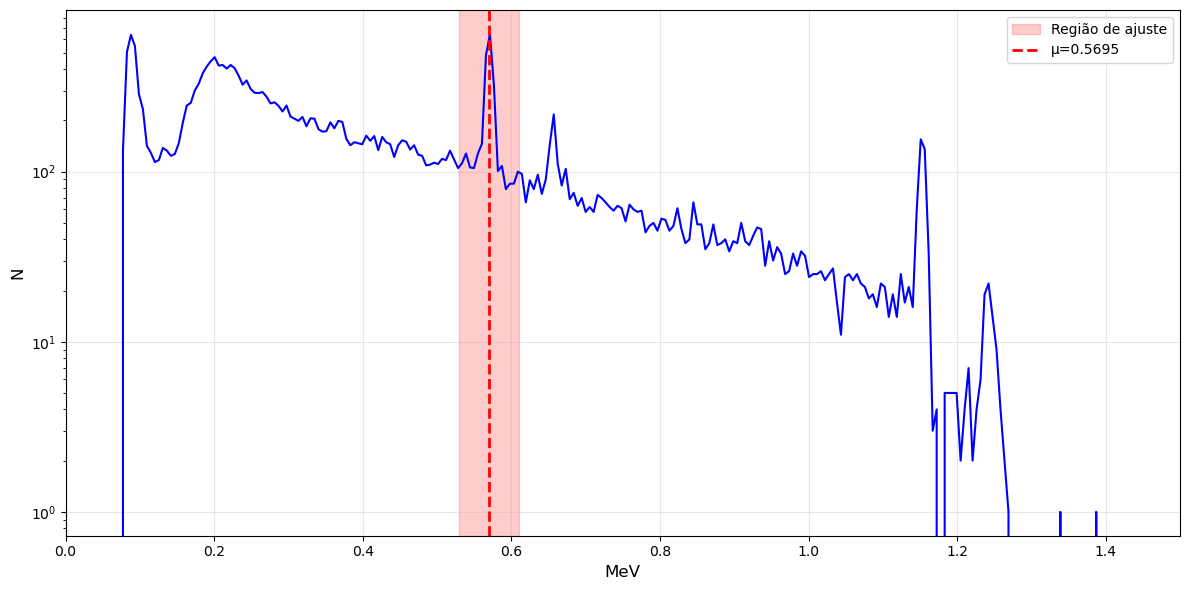

K-shell 01: 
  μ = 0.5695 ± 0.0003; χ²_red = nan


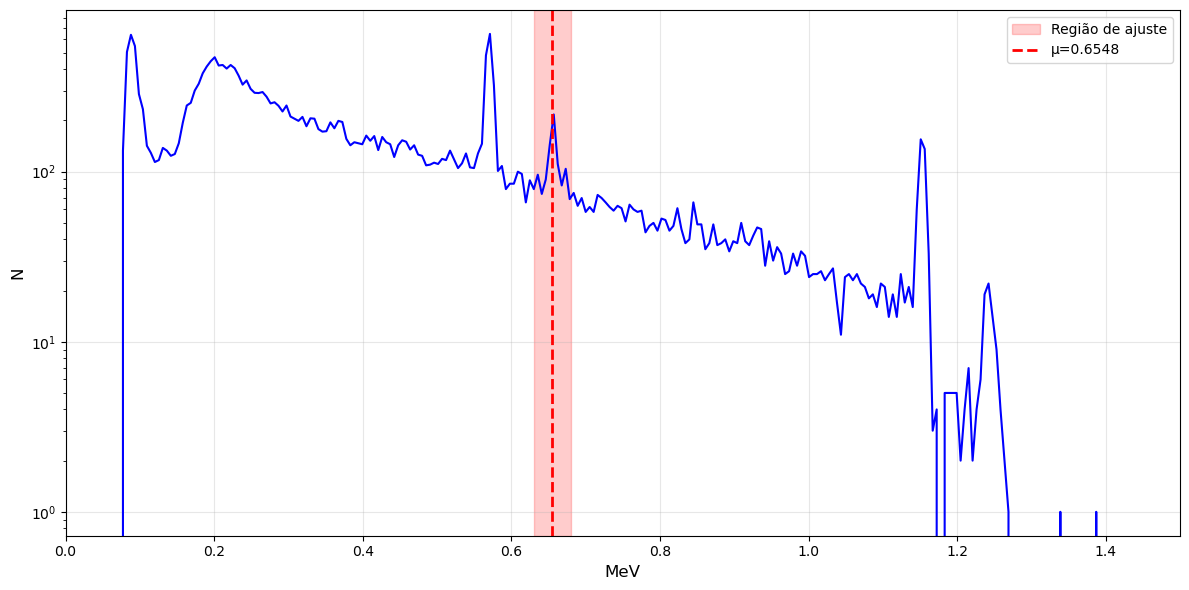

L-shell 01: 
  μ = 0.6548 ± 0.0004; χ²_red = nan


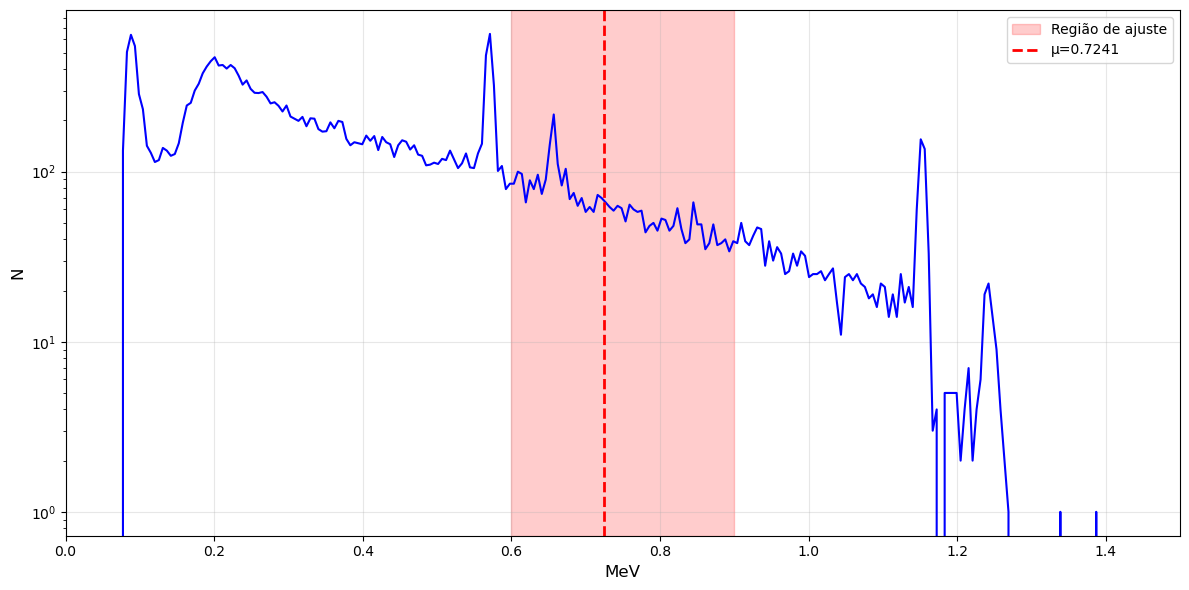

K-shell 02: 
  μ = 0.7241 ± 0.0014; χ²_red = nan


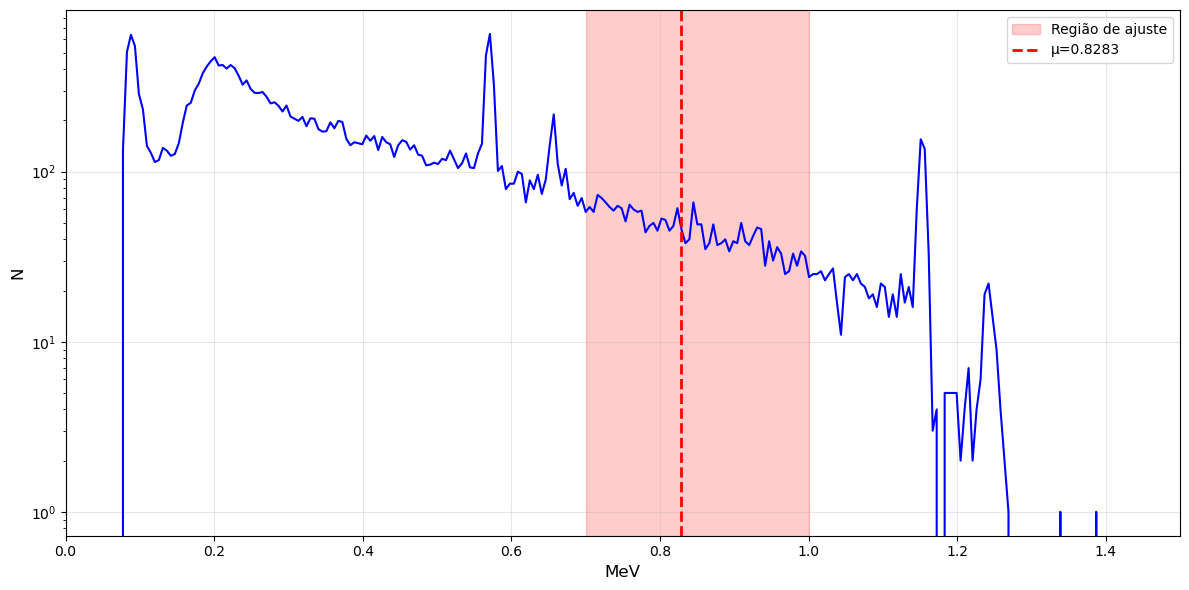

L-shell 02: 
  μ = 0.8283 ± 0.0017; χ²_red = nan


In [76]:
channels_bi, counts_bi = load_spectrum('BIPR3.ASC')
energies_bi, sigma_energies_bi = calib(channels_bi)

k_roi_01_min, k_roi_01_max = 0.53, 0.61
l_roi_01_min, l_roi_01_max = 0.63, 0.68
k_roi_02_min, k_roi_02_max = 0.6, 0.9
l_roi_02_min, l_roi_02_max = 0.7, 1.0

k_roi_01 = (energies_bi >= k_roi_01_min) & (energies_bi <= k_roi_01_max)
mu_k_01, sigma_k_01, chi2_k_01 = compute_stat(energies_bi[k_roi_01], counts_bi[k_roi_01], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_bi, counts_bi, 'b-', linewidth=1.5)
ax.axvspan(k_roi_01_min, k_roi_01_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_k_01, color='red', linestyle='--', linewidth=2, label=f'μ={mu_k_01:.4f}')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_xlim(0 , 1.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K-shell 01: \n  μ = {mu_k_01:.4f} ± {sigma_k_01:.4f}; χ²_red = {chi2_k_01:.4f}")

l_roi_01 = (energies_bi >= l_roi_01_min) & (energies_bi <= l_roi_01_max)
mu_l_01, sigma_l_01, chi2_l_01 = compute_stat(energies_bi[l_roi_01], counts_bi[l_roi_01], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_bi, counts_bi, 'b-', linewidth=1.5)
ax.axvspan(l_roi_01_min, l_roi_01_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_l_01, color='red', linestyle='--', linewidth=2, label=f'μ={mu_l_01:.4f}')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_xlim(0 , 1.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"L-shell 01: \n  μ = {mu_l_01:.4f} ± {sigma_l_01:.4f}; χ²_red = {chi2_l_01:.4f}")

k_roi_02 = (energies_bi >= k_roi_02_min) & (energies_bi <= k_roi_02_max)
mu_k_02, sigma_k_02, chi2_k_02 = compute_stat(energies_bi[k_roi_02], counts_bi[k_roi_02], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_bi, counts_bi, 'b-', linewidth=1.5)
ax.axvspan(k_roi_02_min, k_roi_02_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_k_02, color='red', linestyle='--', linewidth=2, label=f'μ={mu_k_02:.4f}')
ax.set_yscale('log')
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.set_xlim(0 , 1.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K-shell 02: \n  μ = {mu_k_02:.4f} ± {sigma_k_02:.4f}; χ²_red = {chi2_k_02:.4f}")

l_roi_02 = (energies_bi >= l_roi_02_min) & (energies_bi <= l_roi_02_max)
mu_l_02, sigma_l_02, chi2_l_02 = compute_stat(energies_bi[l_roi_02], counts_bi[l_roi_02], model=None)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(energies_bi, counts_bi, 'b-', linewidth=1.5)
ax.axvspan(l_roi_02_min, l_roi_02_max, alpha=0.2, color='red', label='Região de ajuste')
ax.axvline(mu_l_02, color='red', linestyle='--', linewidth=2, label=f'μ={mu_l_02:.4f}')
ax.set_yscale('log')
ax.set_xlim(0 , 1.5)
ax.set_xlabel('MeV', fontsize=12)
ax.set_ylabel('N', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"L-shell 02: \n  μ = {mu_l_02:.4f} ± {sigma_l_02:.4f}; χ²_red = {chi2_l_02:.4f}")